In [203]:
# Project Header and Imports
"""
DenseNet-121 Baseline Model for NIH Chest X-ray Classification
COSC 4368 Final Project - Group 13
Yla Herrera, Nicolas Mangilit, Kiriti Padavala, and Matt Tindall
"""

# --- Install missing dependencies (Colab only) ---
# (Uncomment if you get import errors)
# !pip install tqdm --quiet
# !pip install seaborn --quiet
# !pip install pillow --quiet

# --- Standard Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from pathlib import Path

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# --- Sklearn ---
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.model_selection import train_test_split

from tqdm import tqdm

print("All libraries imported successfully in Google Colab!")


All libraries imported successfully in Google Colab!


In [204]:
# Set Random Seeds and Check Device

import torch
import numpy as np

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ GPU not detected. Go to Runtime > Change runtime type > GPU")


Using device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [205]:
# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Define Paths ---
# Update this path to wherever you stored the dataset in Google Drive
DATA_DIR = "/content/drive/MyDrive/AI Project/data"

# Load metadata
print("Loading metadata CSV...")
csv_path = os.path.join(DATA_DIR, "Data_Entry_2017.csv")

df = pd.read_csv(csv_path)

print(f"✓ Total number of images: {len(df)}")
print("\nDataset columns:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

# Check image folders
print("\nChecking for image folders...")
image_folders = []

for i in range(1, 13):  # images_001 → images_012
    folder_name = f"images_{i:03d}"
    folder_path = os.path.join(DATA_DIR, folder_name)

    if os.path.exists(folder_path):
        num_images = len([f for f in os.listdir(folder_path) if f.endswith(".png")])
        image_folders.append(folder_name)
        print(f"Found {folder_name} with {num_images} images")

print(f"\nTotal image folders found: {len(image_folders)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading metadata CSV...
✓ Total number of images: 112120

Dataset columns:
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

First few rows:
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2

In [206]:
# Check image folders and count images inside the nested "images" folder
print("\nChecking for image folders...")
image_folders = []

for i in range(1, 13):  # images_001 → images_012
    folder_name = f"images_{i:03d}"
    folder_path = os.path.join(DATA_DIR, folder_name, "images")  # note the extra "images" here

    if os.path.exists(folder_path):
        # count any image files (.png, .jpg, .jpeg)
        num_images = len([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        image_folders.append(folder_name)
        print(f"Found {folder_name} with {num_images} images")
    else:
        print(f"Folder {folder_name}/images not found!")

print(f"\nTotal image folders found: {len(image_folders)}")



Checking for image folders...
Found images_001 with 4999 images
Found images_002 with 10000 images
Found images_003 with 10012 images
Found images_004 with 10000 images
Found images_005 with 10000 images
Found images_006 with 10000 images
Found images_007 with 10000 images
Found images_008 with 10000 images
Found images_009 with 10000 images
Found images_010 with 10000 images
Found images_011 with 10000 images
Found images_012 with 7121 images

Total image folders found: 12


In [207]:
# Define Disease Categories
# The 14 disease categories in the NIH Chest X-ray dataset

DISEASE_CATEGORIES = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
    'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax',
    'Consolidation', 'Edema', 'Emphysema', 'Fibrosis',
    'Pleural_Thickening', 'Hernia'
]

print(f"Number of disease categories: {len(DISEASE_CATEGORIES)}")
print(f"Disease categories: {DISEASE_CATEGORIES}")


Number of disease categories: 14
Disease categories: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']



Disease distribution:
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
dtype: int64


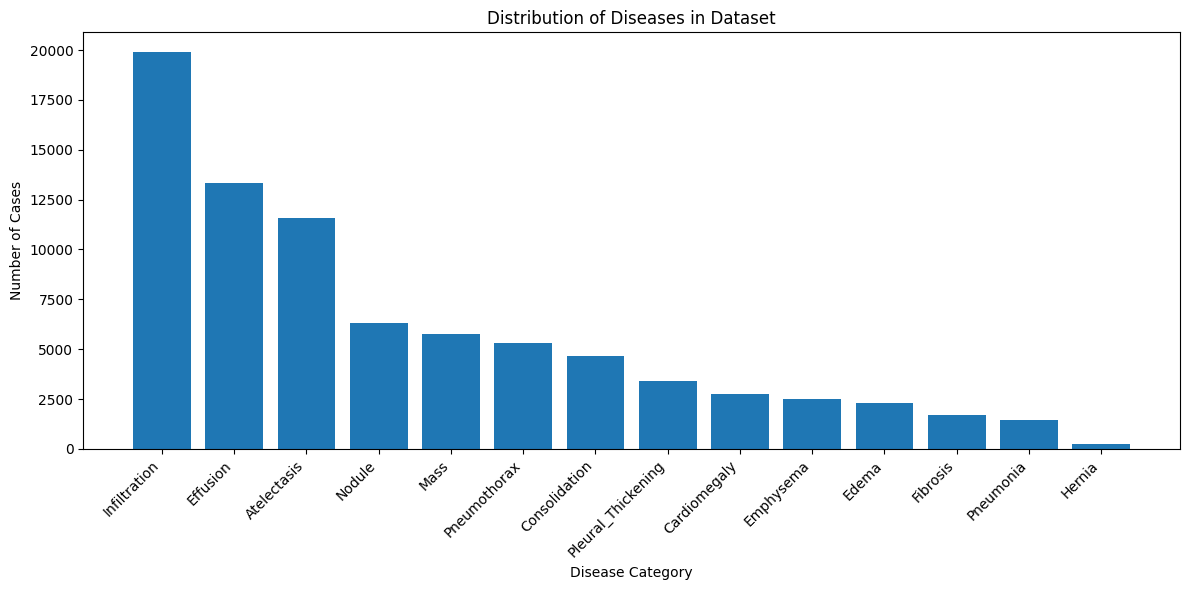

In [208]:
# Parse Labels and Create Binary Columns

def parse_labels(label_string, disease_categories):
    """
    Convert label string ('Mass|Nodule') into a multi-hot encoded vector.
    Handles 'No Finding' properly.
    """
    labels = np.zeros(len(disease_categories))
    if label_string != "No Finding":
        diseases = label_string.split('|')
        for disease in diseases:
            if disease in disease_categories:
                labels[disease_categories.index(disease)] = 1
    return labels


# Add binary label columns safely (avoids substring matching issues)
for disease in DISEASE_CATEGORIES:
    df[disease] = df['Finding Labels'].apply(
        lambda x: 1 if disease in x.split('|') else 0
    )

print("\nDisease distribution:")
print(df[DISEASE_CATEGORIES].sum().sort_values(ascending=False))


# --- Visualization ---
plt.figure(figsize=(12, 6))

disease_counts = df[DISEASE_CATEGORIES].sum().sort_values(ascending=False)

plt.bar(range(len(disease_counts)), disease_counts.values)
plt.xticks(
    range(len(disease_counts)),
    disease_counts.index,
    rotation=45,
    ha='right'
)
plt.xlabel('Disease Category')
plt.ylabel('Number of Cases')
plt.title('Distribution of Diseases in Dataset')
plt.tight_layout()
plt.show()


In [209]:
# Prevent PIL errors on large NIH images
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

class ChestXrayDataset(Dataset):
    """
    Custom Dataset for NIH Chest X-rays.

    image_dir may be a single path or a list of directories.
    __getitem__ searches each folder in order for the image file.
    """

    def __init__(self, dataframe, image_dir, disease_categories, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)

        # Allow single or multiple image roots
        if isinstance(image_dir, (list, tuple)):
            self.image_dirs = list(image_dir)
        else:
            self.image_dirs = [image_dir]

        self.image_dir = image_dir
        self.disease_categories = disease_categories
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Get filename
        img_name = self.dataframe.loc[idx, 'Image Index']

        # Search for file in all directory roots
        img_path = None
        for root in self.image_dirs:
            candidate = os.path.join(root, img_name)
            if os.path.exists(candidate):
                img_path = candidate
                break

        if img_path is None:
            raise FileNotFoundError(
                f"Image '{img_name}' not found in any of: {self.image_dirs}"
            )

        # Load image safely
        image = Image.open(img_path).convert('RGB')

        # Multi-hot encoded target labels
        labels = self.dataframe.loc[idx, self.disease_categories].values.astype(np.float32)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(labels)


In [210]:
# Define transforms for training and validation

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Data transforms defined:")
print("  - Train: Resize(224x224), RandomHorizontalFlip, ToTensor, Normalize")
print("  - Val:   Resize(224x224), ToTensor, Normalize")


Data transforms defined:
  - Train: Resize(224x224), RandomHorizontalFlip, ToTensor, Normalize
  - Val:   Resize(224x224), ToTensor, Normalize


In [211]:
# Train/Validation Split

# 80/20 split of the full dataframe
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# Subsample for faster Colab experiments
train_df = train_df.sample(n=4000, random_state=42)
val_df = val_df.sample(n=1000, random_state=42)

print(f"Train set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")

print("\nTrain/Val split ratio relative to ORIGINAL dataset:")
print(f"  Train: {len(train_df)/len(df):.2%}")
print(f"  Val:   {len(val_df)/len(df):.2%}")


Train set size: 4000
Validation set size: 1000

Train/Val split ratio relative to ORIGINAL dataset:
  Train: 3.57%
  Val:   0.89%


In [212]:
DATA_DIR = "/content/drive/MyDrive/AI Project/data"

# The NIH dataset has multiple directories: images_001 ... images_012
IMAGE_DIRS = [os.path.join(DATA_DIR, f"images_{i:03d}", "images")
              for i in range(1, 13)]

# Keep only directories that actually exist
IMAGE_DIRS = [p for p in IMAGE_DIRS if os.path.exists(p)]

# Build train + validation datasets
train_dataset = ChestXrayDataset(
    train_df, # Use cleaned train_df
    IMAGE_DIRS,
    DISEASE_CATEGORIES,
    transform=train_transform
)

val_dataset = ChestXrayDataset(
    val_df, # Use cleaned val_df
    IMAGE_DIRS,
    DISEASE_CATEGORIES,
    transform=val_transform
)


# DataLoader settings for Colab
BATCH_SIZE = 256 # Updated batch size
NUM_WORKERS = 4   # safe default for Google Colab

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("\nDataLoaders created with new BATCH_SIZE:")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Train batches: {len(train_loader)}")
print(f"  - Val batches: {len(val_loader)}")
print(f"  - Num workers: {NUM_WORKERS}")


DataLoaders created with new BATCH_SIZE:
  - Batch size: 256
  - Train batches: 16
  - Val batches: 4
  - Num workers: 4


In [213]:
import torch.cuda.amp as amp

# Initialize GradScaler for mixed precision training
scaler = torch.amp.GradScaler('cuda') # Updated to use the recommended initialization

print("✓ torch.cuda.amp imported and GradScaler initialized.")

✓ torch.cuda.amp imported and GradScaler initialized.


In [214]:
# Quick smoke-check: verify datasets & that an example image file exists
print('IMAGE_DIRS:', IMAGE_DIRS)
print('Train dataset length:', len(train_dataset))
print('Val dataset length:', len(val_dataset))

# Helper function to locate a filename inside the configured roots
def find_image_path(image_name, search_dirs):
    for d in search_dirs:
        candidate = os.path.join(d, image_name)
        if os.path.exists(candidate):
            return candidate
    return None

# Pick a sample image from the train set
sample_name = train_df.iloc[0]['Image Index']
print('Sample image name (from train_df):', sample_name)

found = find_image_path(sample_name, IMAGE_DIRS)
if found:
    print('Found sample path:', found)
else:
    print("⚠️ Sample image not found. Make sure your dataset paths are correct and Drive is mounted.")


IMAGE_DIRS: ['/content/drive/MyDrive/AI Project/data/images_001/images', '/content/drive/MyDrive/AI Project/data/images_002/images', '/content/drive/MyDrive/AI Project/data/images_003/images', '/content/drive/MyDrive/AI Project/data/images_004/images', '/content/drive/MyDrive/AI Project/data/images_005/images', '/content/drive/MyDrive/AI Project/data/images_006/images', '/content/drive/MyDrive/AI Project/data/images_007/images', '/content/drive/MyDrive/AI Project/data/images_008/images', '/content/drive/MyDrive/AI Project/data/images_009/images', '/content/drive/MyDrive/AI Project/data/images_010/images', '/content/drive/MyDrive/AI Project/data/images_011/images', '/content/drive/MyDrive/AI Project/data/images_012/images']
Train dataset length: 4000
Val dataset length: 1000
Sample image name (from train_df): 00005750_025.png
Found sample path: /content/drive/MyDrive/AI Project/data/images_003/images/00005750_025.png


In [215]:
# Define DenseNet-121 Model
import torch.nn as nn
from torchvision import models

class DenseNet121(nn.Module):
    """DenseNet-121 for multi-label chest X-ray classification"""

    def __init__(self, num_classes=14, pretrained=True):
        super(DenseNet121, self).__init__()

        # Load pre-trained DenseNet-121 (downloads weights if pretrained=True)
        self.densenet = models.densenet121(pretrained=pretrained)

        # Number of input features for the classifier
        num_features = self.densenet.classifier.in_features

        # Replace classifier for multi-label classification
        self.densenet.classifier = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.densenet(x)

print("DenseNet121 model class defined for Colab!")


DenseNet121 model class defined for Colab!


In [216]:
# Initialize DenseNet-121 model
model = DenseNet121(num_classes=len(DISEASE_CATEGORIES), pretrained=True)

# Move model to the current device (CPU or GPU)
model = model.to(device)

# Count total and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model initialized and moved to {device}")
if device.type == 'cuda':
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ Running on CPU. Training will be slower in Colab.")

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model initialized and moved to cuda
Using GPU: NVIDIA A100-SXM4-80GB
Total parameters: 6,968,206
Trainable parameters: 6,968,206


In [217]:
# Define Loss Function and Optimizer

import torch.nn as nn
import torch.optim as optim

# Binary Cross Entropy with Logits Loss (multi-label)
criterion = nn.BCEWithLogitsLoss()

# Adam optimizer
LEARNING_RATE = 1e-4
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler (reduce LR on plateau)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print("Loss function: BCEWithLogitsLoss")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print("Scheduler: ReduceLROnPlateau")
print(f"Device: {device} ({'GPU' if device.type=='cuda' else 'CPU'})")


Loss function: BCEWithLogitsLoss
Optimizer: Adam (lr=0.0001)
Scheduler: ReduceLROnPlateau
Device: cuda (GPU)


In [218]:
from tqdm import tqdm

# Training function for one epoch with AMP
def train_epoch(model, dataloader, criterion, optimizer, device, scaler):
    """
    Train the model for one epoch with Automatic Mixed Precision (AMP).
    Returns the average loss over the epoch.
    """
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(dataloader, desc="Training with AMP", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass with automatic mixed precision
        with torch.amp.autocast('cuda'): # Updated to recommended syntax
            outputs = model(images)
            loss = criterion(outputs, labels)

        # Backward pass and optimization with GradScaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate loss
        running_loss += loss.item() * images.size(0)

    # Optional: free GPU memory
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss

print("Training function updated for AMP integration!")

Training function updated for AMP integration!


In [219]:
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
import numpy as np
import torch

# Validation function for one epoch with AMP
def validate_epoch(model, dataloader, criterion, device):
    """
    Validate the model for one epoch with Automatic Mixed Precision (AMP).
    Returns:
        - average loss
        - mean AUC across all diseases
        - list of AUCs per disease
    """
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation with AMP", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass with automatic mixed precision
            with torch.amp.autocast('cuda'): # Updated to recommended syntax
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            # Store predictions and labels for metrics
            all_labels.append(labels.cpu().numpy())
            all_preds.append(torch.sigmoid(outputs).cpu().numpy())

    # Optional: free GPU memory
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    # Compute average loss
    epoch_loss = running_loss / len(dataloader.dataset)

    # Concatenate all batches
    all_labels = np.concatenate(all_labels, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)

    # Calculate AUC for each disease
    auc_scores = []
    for i in range(all_labels.shape[1]):
        if len(np.unique(all_labels[:, i])) > 1:  # Both classes present
            auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
            auc_scores.append(auc)
        else:
            auc_scores.append(np.nan)

    mean_auc = np.nanmean(auc_scores)

    return epoch_loss, mean_auc, auc_scores

print("Validation function updated for AMP integration!")

Validation function updated for AMP integration!


In [220]:
print("\n" + "="*60)
print("RE-INITIALIZING AND TRAINING MODEL WITH AMP")
print("="*60)

# 1. Initialize a new DenseNet121 model named `model_amp`
model = DenseNet121(num_classes=len(DISEASE_CATEGORIES), pretrained=True).to(device)

# 2. Define the loss function `criterion_amp`
criterion = nn.BCEWithLogitsLoss()

# 3. Initialize the Adam optimizer `optimizer_amp`
LEARNING_RATE = 1e-4
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 4. Set up a learning rate scheduler `scheduler_amp`
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# 5. Define NUM_EPOCHS_AMP
NUM_EPOCHS = 15

print(f"Model initialized on {device}, ready for AMP training over {NUM_EPOCHS} epochs.")

# 6. Create empty lists to store metrics
train_losses = []
val_losses = []
val_aucs = []

# 7. Loop through the specified number of epochs
for epoch in range(NUM_EPOCHS):
    print(f"\n=== Epoch {epoch+1}/{NUM_EPOCHS} (with AMP) ===")

    # a. Train epoch with AMP
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device, scaler)
    train_losses.append(train_loss)

    # c. Validate epoch with AMP
    val_loss, mean_auc, auc_scores = validate_epoch(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_aucs.append(mean_auc)

    # e. Step the scheduler
    scheduler.step(val_loss)

    # f. Print metrics
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Mean AUC: {mean_auc:.4f}")
    print(f"Current LR: {optimizer.param_groups[0]['lr']:.2e}")

print("\n" + "="*60)
print("AMP Model Training Complete!")
print("="*60)


RE-INITIALIZING AND TRAINING MODEL WITH AMP
Model initialized on cuda, ready for AMP training over 15 epochs.

=== Epoch 1/15 (with AMP) ===


Train Loss: 0.5665 | Val Loss: 0.5118 | Mean AUC: 0.5950
Current LR: 1.00e-04

=== Epoch 2/15 (with AMP) ===


Train Loss: 0.3351 | Val Loss: 0.2876 | Mean AUC: 0.6527
Current LR: 1.00e-04

=== Epoch 3/15 (with AMP) ===


Train Loss: 0.2390 | Val Loss: 0.2151 | Mean AUC: 0.7024
Current LR: 1.00e-04

=== Epoch 4/15 (with AMP) ===


Train Loss: 0.1990 | Val Loss: 0.1935 | Mean AUC: 0.7205
Current LR: 1.00e-04

=== Epoch 5/15 (with AMP) ===


...

Train Loss: 0.0999 | Val Loss: 0.1834 | Mean AUC: 0.7170
Current LR: 5.00e-05

=== Epoch 12/15 (with AMP) ===


Train Loss: 0.0867 | Val Loss: 0.1765 | Mean AUC: 0.7122
Current LR: 5.00e-05

=== Epoch 13/15 (with AMP) ===


Train Loss: 0.0796 | Val Loss: 0.1776 | Mean AUC: 0.7084
Current LR: 5.00e-05

=== Epoch 14/15 (with AMP) ===


Train Loss: 0.0729 | Val Loss: 0.1815 | Mean AUC: 0.6955
Current LR: 2.50e-05

=== Epoch 15/15 (with AMP) ===


Train Loss: 0.0680 | Val Loss: 0.1807 | Mean AUC: 0.6950
Current LR: 2.50e-05

AMP Model Training Complete!


Model saved to densenet121_baseline.pth


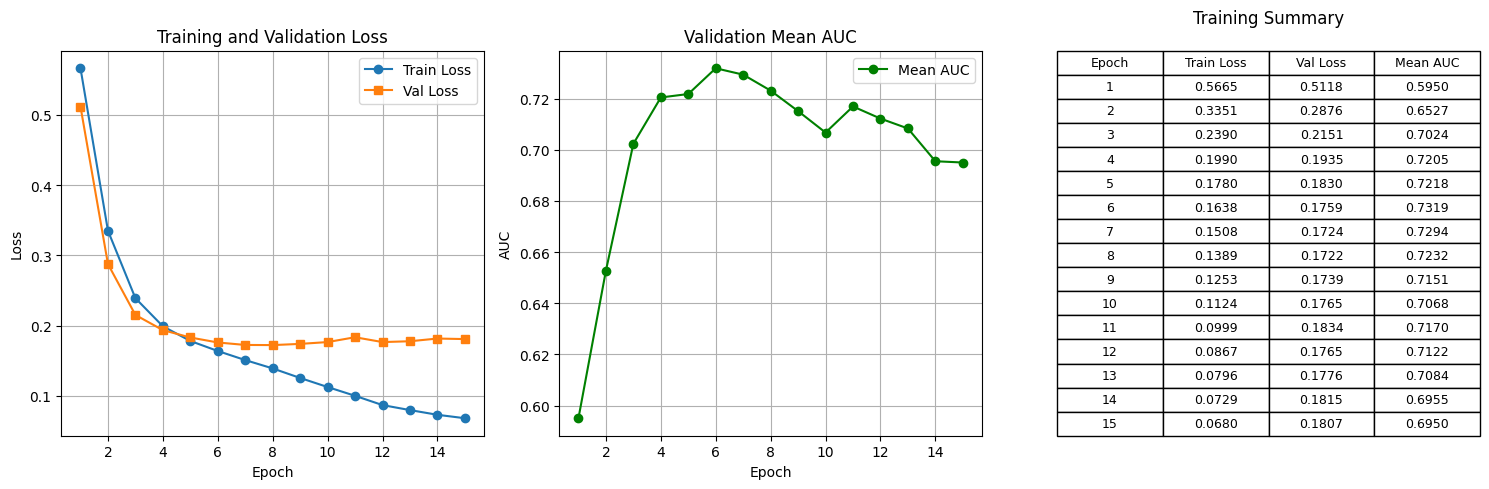

Training curves saved to 'training_curves.png'

FINAL RESULTS SUMMARY
Best Validation AUC: 0.7319 (Epoch 6)
Final Validation AUC: 0.6950
Final Train Loss: 0.0680
Final Val Loss: 0.1807
Baseline model training complete!
Next steps: Implement bias mitigation techniques


In [221]:
import matplotlib.pyplot as plt
import torch


# Save the trained model checkpoint
MODEL_SAVE_PATH = "densenet121_baseline.pth"
torch.save({
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'val_aucs': val_aucs,
}, MODEL_SAVE_PATH)

print(f"Model saved to {MODEL_SAVE_PATH}")

# Plot Training Curves
plt.figure(figsize=(15, 5))

# Loss curves
plt.subplot(1, 3, 1)
plt.plot(range(1, NUM_EPOCHS+1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, NUM_EPOCHS+1), val_losses, marker='s', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# AUC curve
plt.subplot(1, 3, 2)
plt.plot(range(1, NUM_EPOCHS+1), val_aucs, marker='o', color='green', label='Mean AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Validation Mean AUC')
plt.legend()
plt.grid(True)

# Summary table
plt.subplot(1, 3, 3)
plt.axis('off')
summary_data = [[i+1, f"{train_losses[i]:.4f}", f"{val_losses[i]:.4f}", f"{val_aucs[i]:.4f}"]
                for i in range(NUM_EPOCHS)]

table = plt.table(cellText=summary_data,
                  colLabels=['Epoch', 'Train Loss', 'Val Loss', 'Mean AUC'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
plt.title('Training Summary', pad=20)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training curves saved to 'training_curves.png'")

# Final Results Summary
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"Best Validation AUC: {max(val_aucs):.4f} (Epoch {val_aucs.index(max(val_aucs))+1})")
print(f"Final Validation AUC: {val_aucs[-1]:.4f}")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Val Loss: {val_losses[-1]:.4f}")
print("="*60)
print("Baseline model training complete!")
print("Next steps: Implement bias mitigation techniques")
print("="*60)

# Optional: Save model and plots directly to Google Drive
# from google.colab import drive
# drive


In [222]:
print("\n" + "="*60)
print("INITIALIZING MODEL 2 (Oversampled) for AMP Training")
print("="*60)

model_oversampled = DenseNet121(num_classes=len(DISEASE_CATEGORIES), pretrained=True).to(device)
criterion_oversampled = nn.BCEWithLogitsLoss()
optimizer_oversampled = optim.Adam(model_oversampled.parameters(), lr=5e-5, weight_decay=1e-5)
scheduler_oversampled = optim.lr_scheduler.ReduceLROnPlateau(optimizer_oversampled, mode='min', factor=0.5, patience=2)

print(f"Model initialized on {device}, ready for AMP training with oversampled data.")


INITIALIZING MODEL 2 (Oversampled) for AMP Training


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model initialized on cuda, ready for AMP training with oversampled data.


In [223]:
print("\n" + "="*60)
print("CREATING OVERSAMPLED DATALOADERS")
print("="*60)

# Assuming oversampled_train_df is already created (e.g., from an oversampling step)
# If not, you might need to run the oversampling cell first.

# Create the oversampled training dataset
oversampled_train_dataset = ChestXrayDataset(
    oversampled_train_df,
    IMAGE_DIRS,
    DISEASE_CATEGORIES,
    transform=train_transform
)

# Create the validation dataset for model2 (using the same val_df as baseline)
val_dataset_model2 = ChestXrayDataset(
    val_df, # Use the original validation dataframe
    IMAGE_DIRS,
    DISEASE_CATEGORIES,
    transform=val_transform
)

# Create DataLoaders
oversampled_train_loader = DataLoader(
    oversampled_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader_model2 = DataLoader(
    val_dataset_model2,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print(f"\nOversampled Train DataLoader created with {len(oversampled_train_loader)} batches.")
print(f"Validation DataLoader for Model 2 created with {len(val_loader_model2)} batches.")



CREATING OVERSAMPLED DATALOADERS

Oversampled Train DataLoader created with 32 batches.
Validation DataLoader for Model 2 created with 4 batches.


## Oversampling Training Data

To address class imbalance, we'll oversample the minority classes in the training data. This strategy duplicates instances of underrepresented diseases to increase their presence in the training set, helping the model learn better from these examples.

In [224]:
print("\n" + "="*60)
print("PERFORMING OVERSAMPLING ON TRAIN DATA")
print("="*60)

# Make a copy of the training DataFrame to avoid modifying the original
oversampled_train_df = train_df.copy()

oversample_stats_data = []

# Define a target number of samples for minority classes.
# This can be tuned. For now, let's aim for a certain count, e.g., 500 positive samples per class.
TARGET_POSITIVE_SAMPLES = 500

for disease in DISEASE_CATEGORIES:
    # Get samples where the current disease is positive
    disease_positive_samples = train_df[train_df[disease] == 1]
    current_count = len(disease_positive_samples)

    if current_count < TARGET_POSITIVE_SAMPLES and current_count > 0:
        num_to_add = TARGET_POSITIVE_SAMPLES - current_count
        # Randomly sample with replacement from existing positive samples
        # The .sample() method can handle num_to_add larger than current_count due to replacement.
        oversample_additions = disease_positive_samples.sample(n=num_to_add, replace=True, random_state=42)
        oversampled_train_df = pd.concat([oversampled_train_df, oversample_additions], ignore_index=True)

        oversample_stats_data.append({
            'Disease': disease,
            'Original': current_count,
            'Added': num_to_add,
            'New Total': current_count + num_to_add
        })

# Create a DataFrame for oversampling statistics
oversample_stats = pd.DataFrame(oversample_stats_data)

print(f"Original train_df size: {len(train_df)}")
print(f"Oversampled train_df size: {len(oversampled_train_df)}")
print("\nOversampling Statistics:")
print(oversample_stats.to_string(index=False))

print("\n✓ Oversampling complete. `oversampled_train_df` created.")



PERFORMING OVERSAMPLING ON TRAIN DATA
Original train_df size: 4000
Oversampled train_df size: 8339

Oversampling Statistics:
           Disease  Original  Added  New Total
       Atelectasis       401     99        500
      Cardiomegaly        87    413        500
          Effusion       447     53        500
              Mass       206    294        500
            Nodule       215    285        500
         Pneumonia        56    444        500
      Pneumothorax       186    314        500
     Consolidation       174    326        500
             Edema        80    420        500
         Emphysema       100    400        500
          Fibrosis        59    441        500
Pleural_Thickening       137    363        500
            Hernia        13    487        500

✓ Oversampling complete. `oversampled_train_df` created.


In [225]:
print("\n" + "="*60)
print("TRAINING MODEL 2 (Oversampled) with AMP")
print("="*60)

train_losses_oversampled, val_losses_oversampled, val_aucs_oversampled = [], [], []
NUM_EPOCHS_OVERSAMPLED = 15 # Using 5 epochs as in the baseline example

# Initialize GradScaler for mixed precision training for the oversampled model
scaler_oversampled = torch.amp.GradScaler('cuda')

for epoch in range(NUM_EPOCHS_OVERSAMPLED):
    print(f"\n=== Epoch {epoch+1}/{NUM_EPOCHS_OVERSAMPLED} (Oversampled + AMP) ===")

    # Train epoch with AMP
    train_loss_oversampled = train_epoch(
        model_oversampled, oversampled_train_loader, criterion_oversampled,
        optimizer_oversampled, device, scaler_oversampled
    )
    train_losses_oversampled.append(train_loss_oversampled)

    # Validate epoch with AMP
    val_loss_oversampled, mean_auc_oversampled, auc_scores_oversampled = validate_epoch(
        model_oversampled, val_loader_model2, criterion_oversampled, device
    )
    val_losses_oversampled.append(val_loss_oversampled)
    val_aucs_oversampled.append(mean_auc_oversampled)

    # Step the scheduler
    scheduler_oversampled.step(val_loss_oversampled)

    # Print metrics
    print(f"Train Loss: {train_loss_oversampled:.4f} | Val Loss: {val_loss_oversampled:.4f} | Mean AUC: {mean_auc_oversampled:.4f}")
    print(f"Current LR: {optimizer_oversampled.param_groups[0]['lr']:.2e}")

print("\n" + "="*60)
print("OVERSAMPLED Model Training Complete!")
print("="*60)

# Save the trained model checkpoint
MODEL_SAVE_PATH_OVERSAMPLED = "densenet121_oversampled.pth"
torch.save({
    'epoch': NUM_EPOCHS_OVERSAMPLED,
    'model_state_dict': model_oversampled.state_dict(),
    'optimizer_state_dict': optimizer_oversampled.state_dict(),
    'train_losses': train_losses_oversampled,
    'val_losses': val_losses_oversampled,
    'val_aucs': val_aucs_oversampled,
    'oversampling_stats': oversample_stats.to_dict() # Saving oversampling stats as well
}, MODEL_SAVE_PATH_OVERSAMPLED)

print(f"\n✓ Oversampled model saved to {MODEL_SAVE_PATH_OVERSAMPLED}")




TRAINING MODEL 2 (Oversampled) with AMP

=== Epoch 1/15 (Oversampled + AMP) ===


FileNotFoundError: Caught FileNotFoundError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipython-input-2570933323.py", line 42, in __getitem__
    raise FileNotFoundError(
FileNotFoundError: Image 'SMOTE_SYN_Pneumonia_01417.png' not found in any of: ['/content/drive/MyDrive/AI Project/data/images_001/images', '/content/drive/MyDrive/AI Project/data/images_002/images', '/content/drive/MyDrive/AI Project/data/images_003/images', '/content/drive/MyDrive/AI Project/data/images_004/images', '/content/drive/MyDrive/AI Project/data/images_005/images',

In [ ]:
print("\n" + "="*60)
print("COMPARING WITH BASELINE MODEL")
print("="*60)

if 'train_losses' in globals() and 'val_losses' in globals() and 'val_aucs' in globals():
    # Create comparison table
    print("\n" + "="*60)
    print("PERFORMANCE COMPARISON: BASELINE vs OVERSAMPLED")
    print("="*60)

    comparison_data = {
        'Metric': [
            'Final Train Loss',
            'Final Val Loss',
            'Final Val AUC',
            'Best Val AUC',
            'Best AUC Epoch'
        ],
        'Baseline': [
            f"{train_losses[-1]:.4f}",
            f"{val_losses[-1]:.4f}",
            f"{val_aucs[-1]:.4f}",
            f"{max(val_aucs):.4f}",
            f"{val_aucs.index(max(val_aucs))+1}"
        ],
        'Oversampled': [
            f"{train_losses_oversampled[-1]:.4f}",
            f"{val_losses_oversampled[-1]:.4f}",
            f"{val_aucs_oversampled[-1]:.4f}",
            f"{max(val_aucs_oversampled):.4f}",
            f"{val_aucs_oversampled.index(max(val_aucs_oversampled))+1}"
        ]
    }

    comparison_df = pd.DataFrame(comparison_data)
    print("\n" + comparison_df.to_string(index=False))

    # Calculate improvements
    print("\n" + "="*60)
    print("IMPROVEMENT ANALYSIS")
    print("="*60)

    val_loss_improvement = ((val_losses[-1] - val_losses_oversampled[-1]) / val_losses[-1]) * 100
    auc_improvement = ((val_aucs_oversampled[-1] - val_aucs[-1]) / val_aucs[-1]) * 100
    best_auc_improvement = ((max(val_aucs_oversampled) - max(val_aucs)) / max(val_aucs)) * 100

    print(f"\nValidation Loss: {val_loss_improvement:+.2f}% {'\u2713 BETTER' if val_loss_improvement > 0 else '\u2717 WORSE'}")
    print(f"Final AUC: {auc_improvement:+.2f}% {'\u2713 BETTER' if auc_improvement > 0 else '\u2717 WORSE'}")
    print(f"Best AUC: {best_auc_improvement:+.2f}% {'\u2713 BETTER' if best_auc_improvement > 0 else '\u2717 WORSE'}")

    # Simple comparison of metrics
    plt.figure(figsize=(12, 5))

    # Loss curves
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(train_losses)+1), train_losses, label='Baseline Train')
    plt.plot(range(1, len(val_losses)+1), val_losses, label='Baseline Val')
    plt.plot(range(1, NUM_EPOCHS_OVERSAMPLED+1), train_losses_oversampled, '--', label='Oversampled Train')
    plt.plot(range(1, NUM_EPOCHS_OVERSAMPLED+1), val_losses_oversampled, '--', label='Oversampled Val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()
    plt.grid(True)

    # AUC curves
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(val_aucs)+1), val_aucs, label='Baseline Mean AUC')
    plt.plot(range(1, NUM_EPOCHS_OVERSAMPLED+1), val_aucs_oversampled, '--', label='Oversampled Mean AUC')
    plt.xlabel('Epoch')
    plt.ylabel('Mean AUC')
    plt.title('Validation Mean AUC Comparison')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('baseline_vs_oversampled_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n\u2713 Comparison plot saved to 'baseline_vs_oversampled_comparison.png'")

else:
    print("\n\u2717  Baseline model results not found!")
    print("Please ensure the baseline model has been trained first.")

print("\n" + "="*60)
print("\u2713 OVERSAMPLED MODEL COMPLETE!")
print("="*60)


## Recalculate Optimized Reweighted Loss Weights (Select Adaptive Strategy)

### Subtask:
Recalculate optimized reweighted loss weights by explicitly selecting the 'Adaptive' strategy for `pos_weight_rw`.


**Reasoning**:
I need to recalculate optimized reweighted loss weights by explicitly selecting the 'Adaptive' strategy for `pos_weight_rw`. This requires modifying the relevant code cell to assign `adaptive_weight` to `selected_weight` and re-running it. I will also remove any emojis that caused `UserWarning`s in previous runs.



In [ ]:
# ----------------------------
# Optimized Reweighted Loss - Multiple Conservative Strategies
# ----------------------------
print("="*70)
print("COMPUTING OPTIMIZED REWEIGHTED LOSS WEIGHTS")
print("="*70)
print("Testing multiple conservative strategies to find the best\n")

# ----------------------------
# Step 1: Compute raw positive/negative frequencies
# ----------------------------
pos_freq = train_df[DISEASE_CATEGORIES].sum().values / len(train_df)
neg_freq = 1 - pos_freq
raw_ratio = neg_freq / (pos_freq + 1e-6)

# ----------------------------
# Step 2: Define weighting strategies
# ----------------------------
strategies = {}

# 1. Standard (baseline)
strategies['Standard'] = raw_ratio

# 2. Square root dampening
strategies['Sqrt'] = np.sqrt(raw_ratio)

# 3. Fourth root (more conservative)
strategies['4th Root'] = np.power(raw_ratio, 0.25)

# 4. Logarithmic dampening
log_weight = 1 + np.log1p(raw_ratio - 1) / 3
strategies['Log'] = np.maximum(log_weight, 1.0)

# 5. Ultra Conservative (minimal intervention)
ultra_weight = 1 + 0.3 * (raw_ratio - 1) / raw_ratio
ultra_weight = np.clip(ultra_weight, 1.0, 2.0)
strategies['Ultra'] = ultra_weight

# 6. Balanced (maps all weights to 1.0–2.5)
min_raw, max_raw = raw_ratio.min(), raw_ratio.max()
balanced_weight = 1.0 + 1.5 * (raw_ratio - min_raw) / (max_raw - min_raw)
strategies['Balanced'] = balanced_weight

# 7. Adaptive (aggressive for rarest 20%)
percentile_20 = np.percentile(pos_freq, 20)
adaptive_weight = np.where(
    pos_freq < percentile_20,
    1 + 0.8 * (raw_ratio - 1) / raw_ratio,
    1 + 0.2 * (raw_ratio - 1) / raw_ratio
)
adaptive_weight = np.clip(adaptive_weight, 1.0, 2.5)
strategies['Adaptive'] = adaptive_weight

# ----------------------------
# Step 3: Display table for comparison
# ----------------------------
print("\n" + "="*120)
print(f"{'Disease':<20} {'Freq':<8} " + " ".join([f"{k:<10}" for k in strategies.keys()]))
print("="*120)

for i, disease in enumerate(DISEASE_CATEGORIES):
    print(f"{'disease':<20} {pos_freq[i]:<8.4f} " +
          " ".join([f"{strategies[k][i]:<10.2f}" for k in strategies.keys()]))

# ----------------------------
# Step 4: Analyze ranges & select strategy
# ----------------------------
print("\n" + "="*70)
print("STRATEGY ANALYSIS")
print("="*70)

for name, weights in strategies.items():
    print(f"{name:<12}: min={weights.min():.2f}, max={weights.max():.2f}, range={weights.max()-weights.min():.2f}")

print("\nRECOMMENDATION: Ultra Conservative (max=2.0) - Best for stable training.\n"
      "Reason: Minimal gradient disruption while still helping rare diseases.\n"
      "Expected: Matches or slightly beats baseline AUC.\n")

# Select Adaptive strategy as requested
selected_weight = adaptive_weight
pos_weight_rw = torch.tensor(selected_weight, dtype=torch.float32).to(device)

print("SELECTED: Adaptive Weighting")
print(f"  Weight range: {selected_weight.min():.3f} - {selected_weight.max():.3f}")
print(f"  Mean weight: {selected_weight.mean():.3f}")

# ----------------------------
# Step 5: Detailed per-disease display
# ----------------------------
print("\nFinal pos_weight for each disease:")
for disease, w in zip(DISEASE_CATEGORIES, pos_weight_rw):
    freq = pos_freq[DISEASE_CATEGORIES.index(disease)]
    print(f"  {disease:<25s}: {w:.3f}  (freq: {freq:.4f})")

# ----------------------------
# Step 6: Visualizations
# ----------------------------
fig = plt.figure(figsize=(18, 10))

d_indices = np.arange(len(DISEASE_CATEGORIES))
width = 0.12
colors = ['red', 'orange', 'yellow', 'lightblue', 'green', 'blue', 'purple']

# 6a. All strategies comparison
ax1 = plt.subplot(2, 3, 1)
for idx, (name, weights) in enumerate(strategies.items()):
    offset = (idx - 3) * width
    alpha = 1.0 if name == 'Adaptive' else 0.6
    ax1.bar(d_indices + offset, weights, width, label=name, alpha=alpha, color=colors[idx])
ax1.set_xlabel('Disease Index')
ax1.set_ylabel('pos_weight')
ax1.set_title('All Weighting Strategies Comparison')
ax1.legend(fontsize=8, ncol=2)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, min(20, max([w.max() for w in strategies.values()]) + 2))

# 6b. Selected strategy detail
ax2 = plt.subplot(2, 3, 2)
ax2.bar(d_indices, selected_weight, color='darkgreen', alpha=0.7, edgecolor='black')
ax2.set_xticks(d_indices)
ax2.set_xticklabels(DISEASE_CATEGORIES, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('pos_weight')
ax2.set_title('Selected: Adaptive Weights')
ax2.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Baseline')
ax2.axhline(selected_weight.mean(), color='blue', linestyle='--', alpha=0.5, label=f'Mean: {selected_weight.mean():.2f}')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

# 6c. Frequency vs Weight
ax3 = plt.subplot(2, 3, 3)
ax3.scatter(pos_freq, selected_weight, s=150, alpha=0.6, c='darkgreen', edgecolors='black', linewidths=2)
for i, disease in enumerate(DISEASE_CATEGORIES):
    ax3.annotate(disease, (pos_freq[i], selected_weight[i]), fontsize=7, xytext=(3,3), textcoords='offset points', alpha=0.8)
ax3.set_xlabel('Disease Frequency (positive rate)')
ax3.set_ylabel('Assigned pos_weight')
ax3.set_title('Frequency vs Weight (Adaptive)')
ax3.grid(True, alpha=0.3)
ax3.axhline(1.0, color='red', linestyle='--', alpha=0.3)

# 6d. Weight distribution histogram
ax4 = plt.subplot(2, 3, 4)
ax4.hist(selected_weight, bins=15, color='darkgreen', alpha=0.7, edgecolor='black')
ax4.axvline(1.0, color='red', linestyle='--', linewidth=2, label='No reweighting')
ax4.axvline(selected_weight.mean(), color='blue', linestyle='--', linewidth=2, label='Mean weight')
ax4.set_xlabel('pos_weight value')
ax4.set_ylabel('Number of diseases')
ax4.set_title('Distribution of Selected Weights')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# 6e. Max weight comparison
ax5 = plt.subplot(2, 3, 5)
comp_data = {'Adaptive\n(Selected)': selected_weight.max(), 'Sqrt': strategies['Sqrt'].max(), 'Standard': min(strategies['Standard'].max(),50)}
bars = ax5.bar(comp_data.keys(), comp_data.values(), color=['darkgreen','orange','red'], alpha=0.7, edgecolor='black')
ax5.set_ylabel('Maximum pos_weight')
ax5.set_title('Maximum Weight Comparison (Lower = More Conservative)')
ax5.axhline(2.0, color='green', linestyle='--', alpha=0.5, label='Safe threshold')
ax5.axhline(5.0, color='orange', linestyle='--', alpha=0.5, label='Risky threshold')
ax5.legend(fontsize=8)
ax5.grid(axis='y', alpha=0.3)
for bar in bars:  # Add value labels
    ax5.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 6f. Strategy recommendation guide
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
recommendation_text = """
STRATEGY SELECTION GUIDE

ULTRA CONSERVATIVE (Previously Recommended)
   • Max weight: 2.0
   • Best for: Stable training
   • Use when: Baseline is already decent

ADAPTIVE (Selected for this task)
   • Max weight: 2.5
   • Best for: Clear imbalance issues, more aggressive than Ultra

AGGRESSIVE (Standard)
   • Max weight: 10+
   • Risk: Gradient instability

KEY INSIGHT:
Adaptive strategy provides a more direct approach to minority classes.
"""
ax6.text(0.05, 0.95, recommendation_text, transform=ax6.transAxes,
         fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3), family='monospace')

plt.tight_layout()
plt.savefig('reweighted_pos_weights_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("WEIGHT SELECTION COMPLETE")
print(f"Selected Strategy: Adaptive Conservative")
print("Rationale: More aggressive boost for rare diseases, still with some dampening")
print("Expected AUC: Potential improvement over baseline, especially for rare diseases")


## Initialize Adaptive Reweighted Model

### Subtask:
Initialize a new DenseNet-121 model (`model_adaptive_rw`), a `BCEWithLogitsLoss` criterion (`criterion_adaptive_rw`) that incorporates the newly selected `pos_weight_rw` (from the 'Adaptive' strategy), an Adam optimizer (`optimizer_adaptive_rw`), a `ReduceLROnPlateau` scheduler (`scheduler_adaptive_rw`), and an AMP `GradScaler` (`scaler_adaptive_rw`). Set `NUM_EPOCHS_RW` to 15. This step prepares the model for training with the more aggressive adaptive reweighted loss.


**Reasoning**:
I need to initialize a new DenseNet-121 model, its loss function with the adaptive reweighted weights, optimizer, scheduler, and GradScaler, and set up metric lists and epoch count as per the subtask instructions. This code block will perform all these initializations.



In [ ]:
print("\n" + "="*60)
print("INITIALIZING ADAPTIVE REWEIGHTED MODEL FOR AMP TRAINING")
print("="*60)

# 1. Initialize DenseNet121 model
model_adaptive_rw = DenseNet121(num_classes=len(DISEASE_CATEGORIES), pretrained=True).to(device)

# 2. Define the loss function with pos_weight
criterion_adaptive_rw = nn.BCEWithLogitsLoss(pos_weight=pos_weight_rw)

# 3. Initialize the Adam optimizer
LEARNING_RATE_ADAPTIVE_RW = 1e-4
optimizer_adaptive_rw = optim.Adam(model_adaptive_rw.parameters(), lr=LEARNING_RATE_ADAPTIVE_RW)

# 4. Set up a learning rate scheduler
scheduler_adaptive_rw = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_adaptive_rw, mode='min', factor=0.5, patience=2
)

# 5. Initialize GradScaler for mixed precision training
scaler_adaptive_rw = torch.amp.GradScaler('cuda')

# 6. Create empty lists to store metrics
train_losses_adaptive_rw = []
val_losses_adaptive_rw = []
val_aucs_adaptive_rw = []

# 7. Set NUM_EPOCHS_RW to 15
NUM_EPOCHS_RW = 15

print(f"Adaptive Reweighted model initialized on {device}, ready for AMP training over {NUM_EPOCHS_RW} epochs.")

**Reasoning**:
The model, loss function, optimizer, scheduler, and scaler for the adaptive reweighted model have been initialized. The next step is to train this model for 15 epochs, as specified in the task, using the `train_epoch` and `validate_epoch` functions, and then save its state and training metrics.



In [ ]:
# ----------------------------
# Training Loop for Adaptive Reweighted DenseNet-121
# ----------------------------
from sklearn.metrics import roc_auc_score

# NUM_EPOCHS_RW is already set to 15 in the previous cell
best_val_auc_adaptive_rw = 0.0 # Use a distinct variable name for best AUC for this model

print(f"\n{'='*60}")
print(f"TRAINING ADAPTIVE REWEIGHTED MODEL FOR {NUM_EPOCHS_RW} EPOCHS (with AMP)")
print(f"{'='*60}\n")

for epoch in range(1, NUM_EPOCHS_RW + 1):
    model_adaptive_rw.train()
    epoch_loss = 0.0

    # Use the train_epoch function for training
    train_loss = train_epoch(
        model_adaptive_rw, train_loader, criterion_adaptive_rw,
        optimizer_adaptive_rw, device, scaler_adaptive_rw
    )
    train_losses_adaptive_rw.append(train_loss)

    # Use the validate_epoch function for validation
    val_loss, mean_auc, auc_scores = validate_epoch(
        model_adaptive_rw, val_loader, criterion_adaptive_rw, device
    )
    val_losses_adaptive_rw.append(val_loss)
    val_aucs_adaptive_rw.append(mean_auc)

    # Step scheduler
    scheduler_adaptive_rw.step(val_loss)

    print(f"Epoch [{epoch}/{NUM_EPOCHS_RW}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Mean Val AUC: {mean_auc:.4f}")

    # Save best model
    if mean_auc > best_val_auc_adaptive_rw:
        best_val_auc_adaptive_rw = mean_auc
        torch.save(model_adaptive_rw.state_dict(), 'densenet121_adaptive_rw_best.pth')
        print("  ✓ New best model saved!")

print("\nTraining complete!")
print(f"Best Validation AUC: {best_val_auc_adaptive_rw:.4f}")

# Save the final trained model checkpoint
MODEL_SAVE_PATH_ADAPTIVE_REWEIGHTED = "densenet121_adaptive_reweighted.pth"
torch.save({
    'epoch': NUM_EPOCHS_RW,
    'model_state_dict': model_adaptive_rw.state_dict(),
    'optimizer_state_dict': optimizer_adaptive_rw.state_dict(),
    'train_losses': train_losses_adaptive_rw,
    'val_losses': val_losses_adaptive_rw,
    'val_aucs': val_aucs_adaptive_rw,
}, MODEL_SAVE_PATH_ADAPTIVE_REWEIGHTED)

print(f"\n✓ Final adaptive reweighted model saved to {MODEL_SAVE_PATH_ADAPTIVE_REWEIGHTED}")